# Pakistan E-Commerce Sales Analysis

An exploratory analysis of ~1 million orders from Pakistan's largest e-commerce dataset (sourced from [Kaggle](https://www.kaggle.com/datasets/zusmani/pakistans-largest-ecommerce-dataset)).

**Questions this analysis answers:**
1. What share of orders are completed, canceled, or refunded?
2. Which product categories generate the most revenue?
3. How has order volume and revenue trended over time?

**Author:** Sohail Riaz

## 1. Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\USER\Desktop\kaggle data sets\Pakistan Largest Ecommerce Dataset.csv')
df.shape

C:\Users\USER\AppData\Local\Temp\ipykernel_9792\2619113430.py:4: DtypeWarning: Columns (0: status, 1: created_at, 2: sku, 3: increment_id, 4: category_name_1, 5: sales_commission_code, 6: payment_method, 7: Working Date, 8: BI Status, 9:  MV , 10: Customer Since, 11: M-Y, 12: FY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\USER\Desktop\kaggle data sets\Pakistan Largest Ecommerce Dataset.csv')


(1048575, 26)

In [2]:
df.isnull().sum()


item_id                   464051
status                    464066
created_at                464051
sku                       464071
price                     464051
qty_ordered               464051
grand_total               464051
increment_id              464051
category_name_1           464215
sales_commission_code     601229
discount_amount           464051
payment_method            464051
Working Date              464051
BI Status                 464051
 MV                       464051
Year                      464051
Month                     464051
Customer Since            464062
M-Y                       464051
FY                        464051
Customer ID               464062
Unnamed: 21              1048575
Unnamed: 22              1048575
Unnamed: 23              1048575
Unnamed: 24              1048575
Unnamed: 25              1048575
dtype: int64

## 2. Data Cleaning

Initial inspection showed that roughly half of the rows in this file are completely empty, likely from how the dataset was originally exported. These rows are removed below, along with any unnamed placeholder columns.

In [3]:
df = df.dropna(how='all')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print(f"Remaining rows after cleaning: {df.shape[0]}")
print(f"Remaining columns: {df.shape[1]}")

Remaining rows after cleaning: 584524
Remaining columns: 21


## 3. Order Status Breakdown

In [4]:
status_counts = df['status'].value_counts()
status_counts

status
complete          233685
canceled          201249
received           77290
order_refunded     59529
refund              8050
cod                 2859
paid                1159
closed               494
payment_review        57
pending               48
processing            33
holded                31
fraud                 10
pending_paypal         7
exchange               4
\N                     4
Name: count, dtype: int64

**Finding:** Of ~584,500 orders, only 40% (233,685) are marked `complete`. Meanwhile, 46% of orders end up canceled, refunded, or returned (`canceled`: 201,249, `order_refunded`: 59,529, `refund`: 8,050 — a combined 268,828 orders). Only 13% (`received`: 77,290) are still in progress. This is a striking fulfillment gap — nearly half of all orders placed never result in a completed sale, which would be a major red flag for the business to investigate (payment issues, product mismatches, delivery failures, etc.).

## 4. Revenue by Product Category

In [6]:
df.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131.0,complete,2016-07-01,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,cod,7/1/2016,#REF!,"1,950",2016.0,7.0,2016-7,7-2016,FY17,1.0
1,211133.0,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,cod,7/1/2016,Gross,240,2016.0,7.0,2016-7,7-2016,FY17,2.0
2,211134.0,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,cod,7/1/2016,Gross,"2,450",2016.0,7.0,2016-7,7-2016,FY17,3.0
3,211135.0,complete,2016-07-01,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,cod,7/1/2016,Net,360,2016.0,7.0,2016-7,7-2016,FY17,4.0
4,211136.0,order_refunded,2016-07-01,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,cod,7/1/2016,Valid,"1,110",2016.0,7.0,2016-7,7-2016,FY17,5.0


In [7]:
category_revenue = df.groupby('category_name_1')['grand_total'].sum().sort_values(ascending=False)
category_revenue.head(10)

category_name_1
Mobiles & Tablets    2.440791e+09
Appliances           6.568497e+08
Entertainment        5.390480e+08
Women's Fashion      2.825779e+08
Computing            2.025457e+08
Men's Fashion        1.941390e+08
Others               1.924656e+08
Superstore           1.121309e+08
Beauty & Grooming    9.718574e+07
Home & Living        8.821708e+07
Name: grand_total, dtype: float64

**Finding:** `Mobiles & Tablets` dominates revenue at ~PKR 2.44 billion — more than double the combined total of the next two categories (`Appliances`: 656.8M + `Entertainment`: 539.0M = 1.2B). Mobiles & Tablets alone accounts for roughly 51% of revenue among the top 10 categories. This suggests the business is heavily reliant on a single product category, which is a useful insight for inventory and marketing prioritization.

## 5. Revenue Trend Over Time

In [8]:
df['order_month'] = df['created_at'].dt.to_period('M')
monthly_revenue = df.groupby('order_month')['grand_total'].sum()
monthly_revenue

order_month
2016-07    4.329195e+07
2016-08    5.623573e+07
2016-09    9.030933e+07
2016-10    9.806605e+07
2016-11    2.683045e+08
2016-12    8.937768e+07
2017-01    1.189482e+08
2017-02    8.912620e+07
2017-03    1.402030e+08
2017-04    1.609884e+08
2017-05    2.480029e+08
2017-06    2.005613e+08
2017-07    8.074143e+07
2017-08    1.342048e+08
2017-09    7.195583e+07
2017-10    1.194520e+08
2017-11    7.995788e+08
2017-12    8.350282e+07
2018-01    8.867497e+07
2018-02    3.191002e+08
2018-03    4.201420e+08
2018-04    1.120790e+08
2018-05    4.592237e+08
2018-06    2.720037e+08
2018-07    2.653908e+08
2018-08    1.568862e+08
Freq: M, Name: grand_total, dtype: float64

**Finding:** Revenue shows a clear seasonal spike in November both years — November 2016 jumped to PKR 268.3M (up from 98.1M in October) and November 2017 spiked even more dramatically to PKR 799.6M, roughly 6-7x the surrounding months. This pattern strongly suggests a major seasonal sales event (such as an 11.11/Black Friday-style promotion), a key insight for planning inventory and marketing around that period each year.

## 6. Visualization: Revenue Trend Over Time

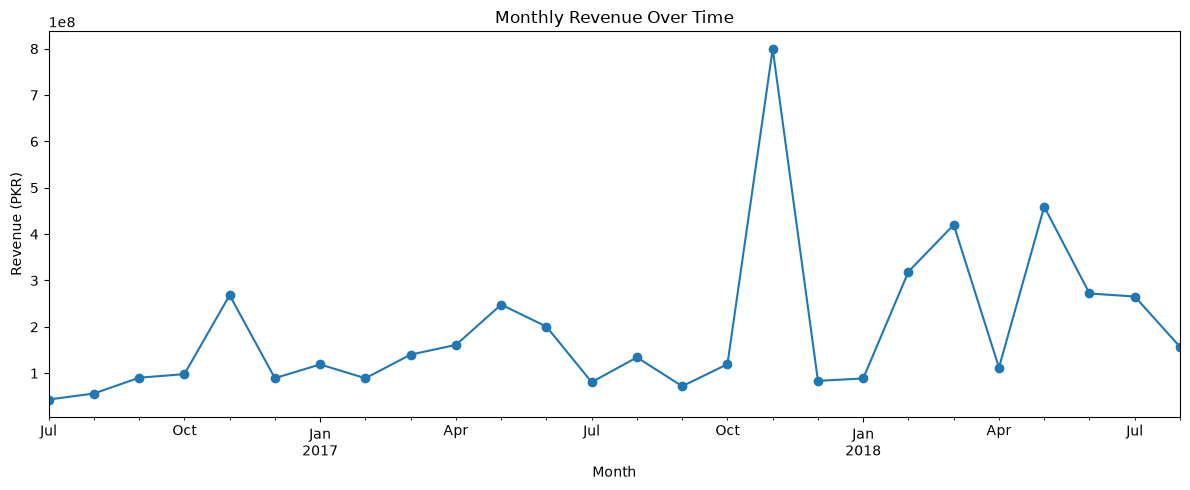

In [9]:
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (PKR)')
plt.tight_layout()
plt.show()

## 7. Visualization: Revenue by Category

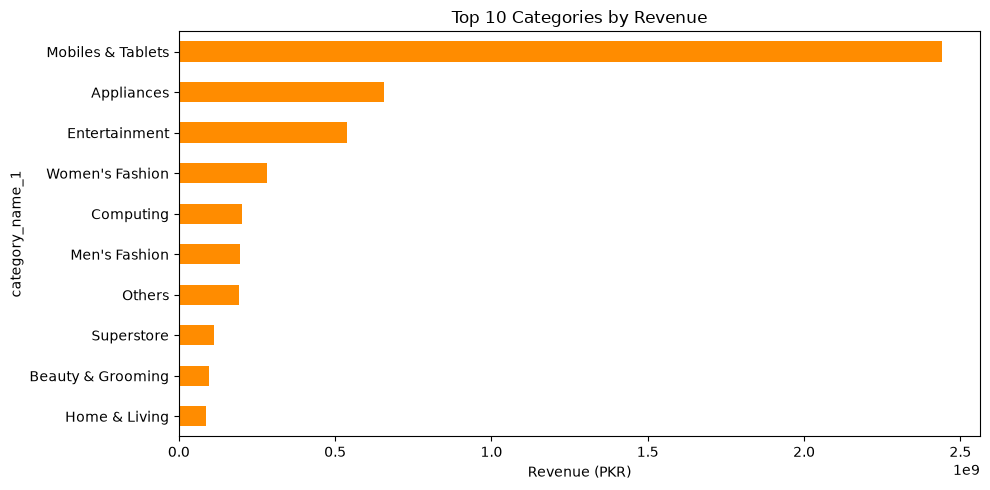

In [10]:
plt.figure(figsize=(10,5))
category_revenue.head(10).plot(kind='barh', color='darkorange')
plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue (PKR)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Key Findings

- **Fulfillment gap:** Only 40% of orders (233,685 of ~584,500) reach `complete` status. Nearly half (46%) end in cancellation, refund, or return — a significant business concern worth root-cause investigation into payment failures, delivery issues, or product mismatches.
- **Category concentration:** `Mobiles & Tablets` generates ~PKR 2.44 billion in revenue, more than the next two categories (`Appliances` and `Entertainment`) combined. The business is heavily dependent on a single category, which carries both opportunity (double down on what works) and risk (limited diversification).
- **Seasonality:** Revenue spikes sharply every November — most dramatically in November 2017 (PKR 799.6M, roughly 6-7x a typical month) — pointing to a major annual sales event. Inventory and marketing planning should anchor around this period.
- **Data quality note:** Roughly half the raw dataset consisted of completely empty rows, which were identified and removed during cleaning before any analysis was performed.
